# 05d — TerSeg (Dual-Branch ResNet-34 + Swin-Tiny)

**Paper**: Fan et al. — *TerSeg: A dual-branch semantic segmentation network for Mars terrain and autonomous path planning*  
DOI: `10.1016/j.eswa.2025.126397` — Expert Systems With Applications 270 (2025)  

**Arquitectura**:  
- **Branch_C**: ResNet-34 pretrained — extrae features locales  
- **Branch_T**: Swin-Tiny (timm, pretrained) — extrae features globales  
- **FL/FG modules**: fusión ponderada entre ramas (local-first en capas tempranas, global-first en capas tardías)  
- **FLGA decoder**: agrega features multi-escala de distintas granularidades  

**Limitación importante**: Swin-Tiny pretrained requiere input 224×224.  
Solución: interpolación de los feature maps de entrada antes de Branch_T, no de la imagen completa.

## 0. Setup

In [1]:
import os, sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/ai4mars_DL-v3')
    sys.path.append(str(PROJECT_ROOT / 'notebooks'))
else:
    # En local: este notebook está en notebooks/, root es el padre
    PROJECT_ROOT = Path.cwd().parent
    if not (PROJECT_ROOT / 'processed').exists():
        PROJECT_ROOT = Path.cwd().parent.parent

print(f'ROOT: {PROJECT_ROOT} | existe: {PROJECT_ROOT.exists()}')

ROOT: c:\Users\User\Documents\DeepLearning\ai4mars_DL-v3 | existe: True


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet34, ResNet34_Weights
import timm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from mars_utils import (
    set_seed, load_norm_stats, load_split,
    build_dataloaders, FocalLoss,
    train_one_epoch, evaluate, train_model, run_multi_seed,
    append_benchmark_results, plot_best_seed_curves,
    print_summary_table, visualize_predictions, count_parameters,
    NUM_CLASSES, IGNORE_INDEX, SEEDS, BENCHMARK_CSV, CHECKPOINTS_DIR
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Configuración

In [3]:
MODEL_NAME   = 'TerSeg'
FAST_SUBSET  = True   # ← True para prueba rápida (~2 min/seed), False para producción

LR           = 1e-4
MAX_EPOCHS   = 80
PATIENCE     = 10
BATCH_SIZE   = 16
FOCAL_ALPHA  = 0.25
FOCAL_GAMMA  = 2.0

# Dimensiones del Swin-Tiny pretrained
SWIN_IMG_SIZE = 224   # ← limitación del pretrained; las imágenes se interpolan internamente

print(f'Modo: {"FAST SUBSET" if FAST_SUBSET else "PRODUCCIÓN"}')
print(f'SWIN input interpolado a: {SWIN_IMG_SIZE}×{SWIN_IMG_SIZE}')

Modo: FAST SUBSET
SWIN input interpolado a: 224×224


## 2. Datos

In [4]:
df_train, df_val, df_gold = load_split()
mean, std = load_norm_stats()

# ── Bug 6 fix: derivar stem de image_path, NO usar df_train['stem'] ──
train_ids = set(Path(p).stem for p in df_train['image_path'])
gold_ids  = set(Path(p).stem for p in df_gold['image_path'])
assert len(train_ids & gold_ids) == 0, '⚠️ DATA LEAKAGE detectado'
print(f'✅ Train: {len(df_train)} | Val: {len(df_val)} | Gold: {len(df_gold)}')
print(f'Normalización — mean: {mean} | std: {std}')

✅ Split cargado — train: 4200 | val: 1800 | gold test: 322
✅ Train: 4200 | Val: 1800 | Gold: 322
Normalización — mean: [0.2303263779898021, 0.2303263779898021, 0.2303263779898021] | std: [0.10591342097577364, 0.10591342097577364, 0.10591342097577364]


## 3. Arquitectura — TerSeg

In [5]:
class FLModule(nn.Module):
    """Focus Local (FL) — fusión donde CNN domina el peso."""
    def __init__(self, cnn_ch: int, swin_ch: int, out_ch: int):
        super().__init__()
        self.align = nn.Conv2d(swin_ch, cnn_ch, 1)
        self.fuse  = nn.Sequential(
            nn.Conv2d(cnn_ch * 2, cnn_ch, 1, bias=False),
            nn.Conv2d(cnn_ch, cnn_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(cnn_ch), nn.ReLU(inplace=True)
        )
        self.proj  = nn.Conv2d(cnn_ch, out_ch, 1) if cnn_ch != out_ch else nn.Identity()

    def forward(self, r, t):
        t_aligned = self.align(
            F.interpolate(t, size=r.shape[-2:], mode='bilinear', align_corners=False)
        )
        gate = torch.sigmoid(self.fuse(torch.cat([r, t_aligned], dim=1)))
        out  = r + gate * r
        return self.proj(out)


class FGModule(nn.Module):
    """Focus Global (FG) — fusión donde Swin domina el peso."""
    def __init__(self, cnn_ch: int, swin_ch: int, out_ch: int):
        super().__init__()
        self.align = nn.Conv2d(cnn_ch, swin_ch, 1)
        self.fuse  = nn.Sequential(
            nn.Conv2d(swin_ch * 2, swin_ch, 1, bias=False),
            nn.Conv2d(swin_ch, swin_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(swin_ch), nn.ReLU(inplace=True)
        )
        self.proj  = nn.Conv2d(swin_ch, out_ch, 1) if swin_ch != out_ch else nn.Identity()

    def forward(self, r, t):
        r_aligned = self.align(
            F.interpolate(r, size=t.shape[-2:], mode='bilinear', align_corners=False)
        )
        gate = torch.sigmoid(self.fuse(torch.cat([r_aligned, t], dim=1)))
        out  = t + gate * t
        return self.proj(out)

In [6]:
class FLGADecoder(nn.Module):
    """Focus on Local and Global feature Aggregation (FLGA)."""
    def __init__(self, in_channels_list: list, c1_ch: int,
                 mid_ch: int, num_classes: int):
        super().__init__()
        n = len(in_channels_list)

        self.blends = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch, mid_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True)
            ) for ch in in_channels_list
        ])

        self.spatial_fuse = nn.Sequential(
            nn.Conv2d(mid_ch * n, mid_ch, 1, bias=False),
            nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True)
        )

        self.c1_reduce = nn.Sequential(
            nn.Conv2d(c1_ch, mid_ch // 4, 1, bias=False),
            nn.BatchNorm2d(mid_ch // 4), nn.ReLU(inplace=True)
        )
        self.final_conv = nn.Sequential(
            nn.Conv2d(mid_ch + mid_ch // 4, mid_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid_ch), nn.ReLU(inplace=True)
        )
        self.head = nn.Conv2d(mid_ch, num_classes, 1)

    def forward(self, fused_list: list, c1: torch.Tensor, out_size: tuple):
        target_h = out_size[0] // 2
        target_w = out_size[1] // 2

        blended = []
        for feat, blend in zip(fused_list, self.blends):
            up = F.interpolate(feat, size=(target_h, target_w),
                               mode='bilinear', align_corners=False)
            blended.append(blend(up))

        FC = self.spatial_fuse(torch.cat(blended, dim=1))
        FA = sum(blended)
        FI = FC + FC * FA

        c1_up = F.interpolate(c1, size=(target_h, target_w),
                              mode='bilinear', align_corners=False)
        c1_r  = self.c1_reduce(c1_up)
        combined = self.final_conv(torch.cat([FI, c1_r], dim=1))

        out = F.interpolate(self.head(combined), size=out_size,
                            mode='bilinear', align_corners=False)
        return out

In [7]:
class TerSeg(nn.Module):
    """TerSeg: dual-branch ResNet-34 + Swin-Tiny."""
    def __init__(self, num_classes: int = 4, swin_img_size: int = 224):
        super().__init__()
        self.swin_img_size = swin_img_size

        # Branch_C: ResNet-34
        rn = resnet34(weights=ResNet34_Weights.DEFAULT)
        self.c_stem   = nn.Sequential(rn.conv1, rn.bn1, rn.relu, rn.maxpool)
        self.c_layer1 = rn.layer1   # 64ch,  H/4
        self.c_layer2 = rn.layer2   # 128ch, H/8
        self.c_layer3 = rn.layer3   # 256ch, H/16
        self.c_layer4 = rn.layer4   # 512ch, H/32

        # Branch_T: Swin-Tiny
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224',
            pretrained=True,
            features_only=True,
            out_indices=(0, 1, 2, 3)
        )
        swin_chs = [96, 192, 384, 768]
        cnn_chs  = [64, 128, 256, 512]

        # Módulos de fusión
        self.fl1 = FLModule(cnn_chs[0], swin_chs[0], cnn_chs[0])
        self.fl2 = FLModule(cnn_chs[1], swin_chs[1], cnn_chs[1])
        self.fg3 = FGModule(cnn_chs[2], swin_chs[2], swin_chs[2])
        self.fg4 = FGModule(cnn_chs[3], swin_chs[3], swin_chs[3])

        fused_chs = [cnn_chs[0], cnn_chs[1], swin_chs[2], swin_chs[3]]

        # Decoder FLGA
        self.decoder = FLGADecoder(
            in_channels_list = fused_chs,
            c1_ch            = cnn_chs[0],
            mid_ch           = 128,
            num_classes      = num_classes
        )

    def _swin_forward(self, x):
        x_swin = F.interpolate(x, size=(self.swin_img_size, self.swin_img_size),
                               mode='bilinear', align_corners=False)
        feats = self.swin(x_swin)
        return [f.permute(0, 3, 1, 2).contiguous() for f in feats]

    def forward(self, x):
        H, W = x.shape[-2:]

        c0 = self.c_stem(x)
        c1 = self.c_layer1(c0)
        c2 = self.c_layer2(c1)
        c3 = self.c_layer3(c2)
        c4 = self.c_layer4(c3)

        t1, t2, t3, t4 = self._swin_forward(x)

        f1 = self.fl1(c1, t1)
        f2 = self.fl2(c2, t2)
        f3 = self.fg3(c3, t3)
        f4 = self.fg4(c4, t4)

        out = self.decoder([f1, f2, f3, f4], c1=c1, out_size=(H, W))
        return out


def build_model():
    return TerSeg(num_classes=NUM_CLASSES, swin_img_size=SWIN_IMG_SIZE).to(DEVICE)


# Verificación
_m = build_model()
_m.eval()
with torch.no_grad():
    _x = torch.randn(2, 3, 256, 256).to(DEVICE)
    _out = _m(_x)
    print(f'Forward OK — salida: {_out.shape}')

n_params = count_parameters(_m)
print(f'Parámetros entrenables: {n_params:.2f}M  (referencia KB: ~49.19M)')
del _m, _x, _out

Forward OK — salida: torch.Size([2, 4, 256, 256])
Parámetros entrenables: 59.47M  (referencia KB: ~49.19M)


## 4. Loss, Optimizer y Scheduler

In [8]:
def criterion_fn():
    return FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA,
                     ignore_index=IGNORE_INDEX)


def optimizer_fn(params):
    return torch.optim.Adam(params, lr=LR)


def scheduler_fn(optimizer):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=5, factor=0.5, verbose=True
    )


print('✅ Loss: FocalLoss (α=0.25, γ=2.0)')
print('  Optimizer: Adam (lr=1e-4)')
print('  Scheduler: ReduceLROnPlateau (mode=max, patience=5, factor=0.5)')

✅ Loss: FocalLoss (α=0.25, γ=2.0)
  Optimizer: Adam (lr=1e-4)
  Scheduler: ReduceLROnPlateau (mode=max, patience=5, factor=0.5)


## 5. Entrenamiento Multi-Seed

⚠️ **Bug 7 fix**: NO pasar `mean`, `std`, `max_epochs`. Usar `num_epochs`.

In [9]:
summary = run_multi_seed(
    model_fn       = build_model,
    df_train       = df_train,
    df_val         = df_val,
    df_gold        = df_gold,
    criterion_fn   = criterion_fn,
    optimizer_fn   = optimizer_fn,
    scheduler_fn   = scheduler_fn,
    model_name     = MODEL_NAME,
    device         = DEVICE,
    num_epochs     = MAX_EPOCHS,   # ← 'num_epochs', no 'max_epochs'
    patience       = PATIENCE,
    batch_size     = BATCH_SIZE,
    fast_subset    = FAST_SUBSET,
    n_train_fast   = 200,
    n_val_fast     = 50,
)
# mean y std NO van aquí — run_multi_seed los carga con load_norm_stats()

Progreso encontrado — seeds completados: {42, 123}

  Seed 42 ya completado — saltando

  Seed 123 ya completado — saltando

───────────────────────────────────────────────────────
  Seed 7 | TerSeg
⚡ Subset rápido — train: 200 | val: 50
   (Para entrenamiento real usar df_train y df_val completos)


c:\Users\User\miniconda3\envs\mars_dl\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Checkpoint periódico encontrado — reanudando desde TerSeg_seed7_periodic.pth
  Reanudando desde epoch 26 | best_miou: 0.7332

  TerSeg_seed7 | device=cuda | AMP=True
  epochs=80 | patience=10 | aux_weight=0.0
Ep  26/80 | loss=0.0039 mIoU=0.8946 | val_loss=0.0134 val_mIoU=0.7146 | rock=0.1336
Ep  27/80 | loss=0.0027 mIoU=0.9179 | val_loss=0.0145 val_mIoU=0.7013 | rock=0.0903
Ep  28/80 | loss=0.0027 mIoU=0.9164 | val_loss=0.0122 val_mIoU=0.7168 | rock=0.1121
Ep  29/80 | loss=0.0024 mIoU=0.9245 | val_loss=0.0121 val_mIoU=0.7168 | rock=0.1095
Ep  30/80 | loss=0.0022 mIoU=0.9238 | val_loss=0.0110 val_mIoU=0.7223 | rock=0.1114
Checkpoint periódico guardado (epoch 30)
Ep  31/80 | loss=0.0022 mIoU=0.9340 | val_loss=0.0112 val_mIoU=0.7332 | rock=0.1504
Ep  32/80 | loss=0.0022 mIoU=0.9257 | val_loss=0.0130 val_mIoU=0.7289 | rock=0.1499
  Early stopping en epoch 32 (sin mejora por 10 epochs)

  Mejor val mIoU=0.7332 (epoch 22) | tiempo=368s
 Checkpoint periódico eliminado
  Gold test mIoU=0.8196


## 6. Resultados Agregados

In [10]:
print_summary_table(summary)


  RESUMEN — TerSeg
  Métrica                 Media       Std      IC95
  ------------------------------------------------
  mIoU                   0.7542    0.0468  ± 0.0530
  Pixel Accuracy         0.9601
  ------------------------------------------------
  IoU soil               0.9461    0.0147
  IoU bedrock            0.8904    0.0187
  IoU sand               0.9157    0.0166
  IoU big_rock           0.2648    0.1445
  ------------------------------------------------
  Params (M)           —
  Tiempo medio (s)         2307
  Epoch mejor (mean)       11.0



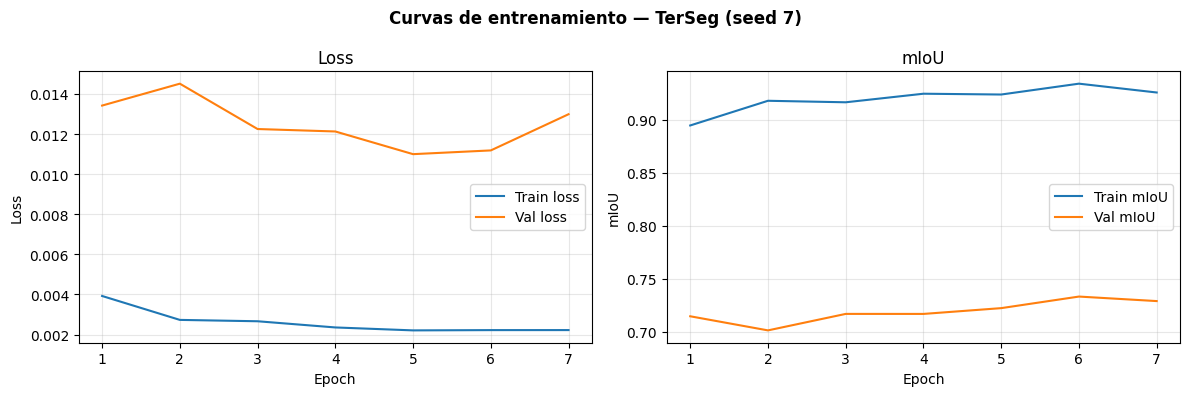

In [11]:
plot_best_seed_curves(summary)

In [12]:
# ── Bug 9 fix: limpiar fila anterior del mismo modelo ──
if BENCHMARK_CSV.exists():
    df_csv = pd.read_csv(BENCHMARK_CSV)
    df_csv = df_csv[df_csv["model"] != MODEL_NAME]
    df_csv.to_csv(BENCHMARK_CSV, index=False)

params_M = count_parameters(build_model())
append_benchmark_results(summary, params_M=params_M)
print('✅ Resultados guardados en results/benchmark_results.csv')

Resultados guardados en C:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\results\benchmark_results.csv
✅ Resultados guardados en results/benchmark_results.csv


## 7. Visualización Cualitativa

⚠️ **Bug 8 fix**: summary NO tiene 'best_seed' ni 'checkpoints'. Calcular manualmente.

Mejor seed: 7 | mIoU gold: 0.8196


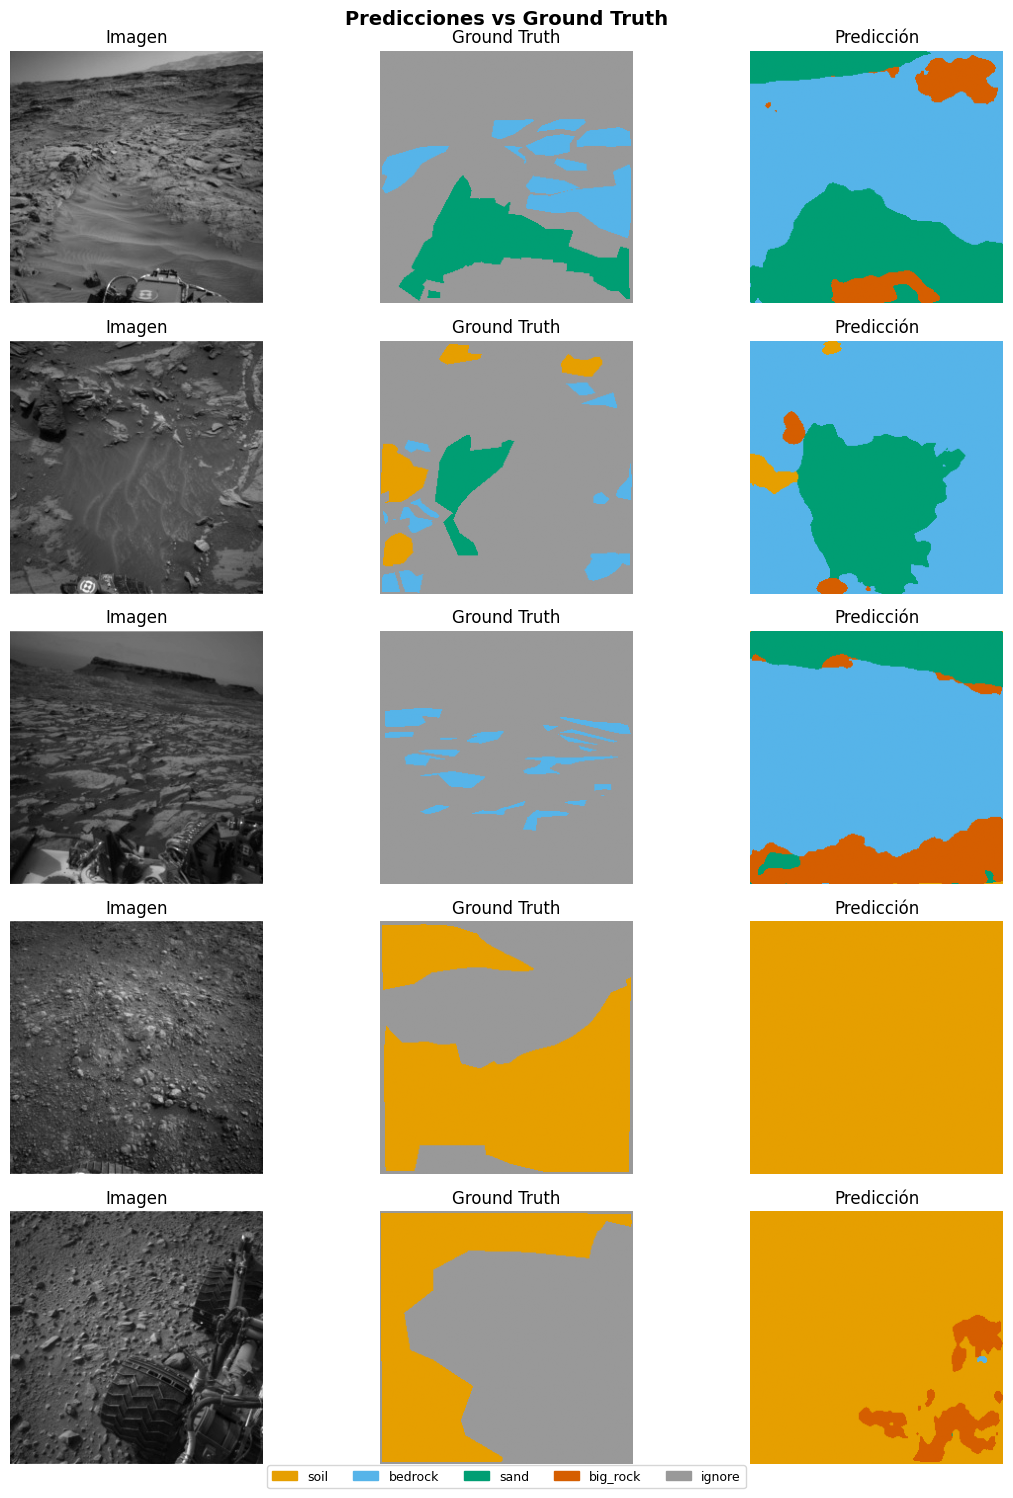

In [13]:
# ── Bug 8 fix: derivar best_seed manualmente ──
best_seed = max(summary["per_seed"], key=lambda r: r["mIoU"])["seed"]
best_miou = max(summary['per_seed'], key=lambda r: r['mIoU'])['mIoU']
ckpt_path = CHECKPOINTS_DIR / f"{MODEL_NAME}_seed{best_seed}_best.pth"

print(f"Mejor seed: {best_seed} | mIoU gold: {best_miou:.4f}")

best_model = build_model().to(DEVICE)
ckpt = torch.load(ckpt_path, map_location=DEVICE)
best_model.load_state_dict(ckpt["model_state"])
best_model.eval()

visualize_predictions(best_model, df_gold, DEVICE, mean=mean, std=std, n=5)

## 8. Resumen Final

| Campo | Valor |
|-------|-------|
| Modelo | TerSeg |
| Paper | Fan et al., Expert Systems with Applications 270 (2025) |
| Branch CNN | ResNet-34 pretrained |
| Branch Transformer | Swin-Tiny (timm) |
| Fusión | FL (stages 1-2) + FG (stages 3-4) |
| Decoder | FLGA multi-escala |
| Loss | FocalLoss (α=0.25, γ=2.0) |
| Optimizer | Adam (lr=1e-4) |
| Scheduler | ReduceLROnPlateau (patience=5, factor=0.5) |
| Swin input | Interpolado a 224×224 internamente |
| Referencia histórica (2.1k imgs) | mIoU = 0.7498 ± 0.0089 |

---
*Resultados del gold set exportados a `results/benchmark_results.csv`.*